In [1]:
from tensorflow_text.tools.wordpiece_vocab import bert_vocab_from_dataset as bert_vocab
import tensorflow as tf
import pandas as pd
import tensorflow_text

In [2]:
df_in = pd.read_csv('t-in_voc', sep='\t', header=None)
df_in.columns = ['book', 'ch', 'verse', 'text']
df_in.head()

,book,ch,verse,text
0,Gen,1,1,B.:R;>CIJT B.@R@> >:ELOHIJM >;T HAC.@MAJIM W:>...
1,Gen,1,2,W:H@>@REY H@J:T@H TOHW. W@BOHW. W:XOCEK: <AL P...
2,Gen,1,3,WAJ.O>MER >:ELOHIJM J:HIJ >OWR WAJ:HIJ >OWR
3,Gen,1,4,WAJ.AR:> >:ELOHIJM >ET H@>OWR K.IJ VOWB WAJ.AB...
4,Gen,1,5,WAJ.IQ:R@> >:ELOHIJM L@>OWR JOWM W:LAXOCEK: Q@...


In [3]:
train_data = tf.data.Dataset.from_tensors(df_in['text'].values)

In [4]:
reserved_tokens=["[PAD]", "[UNK]", "[START]", "[END]"]
vocab = bert_vocab.bert_vocab_from_dataset(train_data, 1000, reserved_tokens)

In [5]:
vocab[:100]

['[PAD]',
 '[UNK]',
 '[START]',
 '[END]',
 '*',
 '.',
 ':',
 ';',
 '<',
 '>',
 '@',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'WAJ',
 'HW',
 'ET',
 'IJ',
 'AL',
 'ACER',
 'LO',
 'AR',
 'JW',
 'EL',
 'IM',
 'HAM',
 'AM',
 'IJM',
 'AT',
 'AX',
 'EH',
 'OW',
 'JIF',
 'RW',
 'AD',
 'AB',
 'IC',
 'MER',
 'OWT',
 '##W',
 'EN',
 'NW',
 'AN',
 'RIJM',
 'JHEM',
 'IJC',
 'WAT',
 'NIJ',
 'OH',
 'JN',
 'HAJ',
 'MAR',
 '##IJ',
 'HAC',
 'JT',
 'KEM',
 'MA',
 'IT',
 'REY',
 'HAK',
 'IB',
 'MIC',
 '##IJM',
 'LOW',
 'MIN',
 'IJR',
 'BW',
 'ELEK',
 'HAZ',
 'HAN',
 'HIJ',
 'HIN',
 'AC',
 'IQ',
 'AK',
 'WA',
 'HAB']

In [6]:
def write_vocab_file(filepath, vocab):
    with open(filepath, 'w') as f:
        for token in vocab:
            print(token, file=f)
        
write_vocab_file('t-in_voc_vocab.txt', vocab)

In [7]:
tokenizer = tensorflow_text.BertTokenizer('t-in_voc_vocab.txt')

In [47]:
examples = [tf.constant(x) for x in df_in['text']]

In [48]:
token_batch = tokenizer.tokenize(examples) #tf.constant(df_in['text'][0]))
# (batch, word, word-piece)
token_batch = token_batch.merge_dims(-2,-1)
token_batch.shape

TensorShape([22946, None])

In [49]:
for ex in token_batch.to_list()[:10]:
    print(ex)

[12, 5, 6, 28, 7, 9, 707, 12, 5, 10, 28, 10, 9, 9, 6, 107, 9, 7, 30, 76, 5, 10, 203, 33, 6, 9, 7, 30, 18, 10, 9, 10, 81]
[33, 6, 18, 10, 9, 10, 81, 18, 10, 20, 6, 30, 10, 18, 545, 388, 5, 33, 10, 141, 388, 5, 33, 6, 972, 6, 8, 41, 26, 5, 6, 24, 7, 20, 30, 6, 594, 151, 33, 6, 56, 5, 126, 9, 6, 107, 23, 6, 409, 398, 159, 8, 41, 26, 5, 6, 24, 7, 20, 48, 5, 10, 116]
[37, 5, 25, 9, 60, 9, 6, 107, 20, 6, 93, 9, 142, 37, 6, 93, 9, 142]
[37, 5, 44, 6, 9, 9, 6, 107, 9, 39, 18, 10, 9, 142, 21, 5, 40, 257, 37, 5, 58, 6, 14, 5, 7, 22, 9, 6, 107, 12, 5, 7, 72, 18, 10, 9, 142, 33, 5, 12, 7, 72, 313, 733, 208, 6]
[37, 5, 96, 6, 28, 10, 9, 9, 6, 107, 22, 10, 9, 142, 180, 33, 6, 171, 733, 208, 6, 27, 10, 28, 10, 9, 22, 10, 20, 6, 22, 10, 18, 37, 6, 93, 8, 606, 37, 6, 93, 141, 163, 185, 180, 9, 108, 10, 14]
[37, 5, 25, 9, 60, 9, 6, 107, 20, 6, 93, 28, 10, 282, 8, 11, 12, 5, 6, 321, 6, 48, 5, 10, 116, 256, 192, 75, 79, 167, 6, 14, 5, 323, 12, 5, 7, 72, 203, 22, 10, 23, 10, 116]
[37, 5, 11, 8, 125, 9, 6, 

In [51]:
txt_tokens = tf.gather(vocab, token_batch[:10])
txt_tokens = tf.strings.reduce_join(txt_tokens, separator=' ', axis=-1)
for t1, t2 in zip(df_in['text'][:10], txt_tokens):
    print(t1)
    print(str(t2.numpy()))
    print()

B.:R;>CIJT B.@R@> >:ELOHIJM >;T HAC.@MAJIM W:>;T H@>@REY
b'B . : R ; > CIJT B . @ R @ > > : ELOHIJM > ; T HAC . @ MAJIM W : > ; T H @ > @ REY'

W:H@>@REY H@J:T@H TOHW. W@BOHW. W:XOCEK: <AL P.:N;J T:HOWM W:RW.XA >:ELOHIJM M:RAXEPET <AL P.:N;J HAM.@JIM
b'W : H @ > @ REY H @ J : T @ H TO ##HW . W @ BO ##HW . W : XOCEK : < AL P . : N ; J T : HOW ##M W : RW . XA > : ELOHIJM M : RAX ##EP ##ET < AL P . : N ; J HAM . @ JIM'

WAJ.O>MER >:ELOHIJM J:HIJ >OWR WAJ:HIJ >OWR
b'WAJ . O > MER > : ELOHIJM J : HIJ > OWR WAJ : HIJ > OWR'

WAJ.AR:> >:ELOHIJM >ET H@>OWR K.IJ VOWB WAJ.AB:D.;L >:ELOHIJM B.;JN H@>OWR W.B;JN HAXOCEK:
b'WAJ . AR : > > : ELOHIJM > ET H @ > OWR K . IJ VOWB WAJ . AB : D . ; L > : ELOHIJM B . ; JN H @ > OWR W . B ; JN HAX ##OC ##EK :'

WAJ.IQ:R@> >:ELOHIJM L@>OWR JOWM W:LAXOCEK: Q@R@> L@J:L@H WAJ:HIJ <EREB WAJ:HIJ BOQER JOWM >EX@D
b'WAJ . IQ : R @ > > : ELOHIJM L @ > OWR JOWM W : LAX ##OC ##EK : Q @ R @ > L @ J : L @ H WAJ : HIJ < EREB WAJ : HIJ BO ##Q ##ER JOWM > EX @ D'

WAJ.O>MER

So how much does this compress?
We compare the distribution of number of subwords per verse, with the number of characters and the number of words

In [56]:
df_in['nr_subwords'] = [len(x) for x in token_batch.to_list()]

In [62]:
df_in['nr_char'] = [len(x) for x in df_in['text']]
df_in['nr_tokens'] = [len(x.split(' ')) for x in df_in['text']]

<AxesSubplot:>

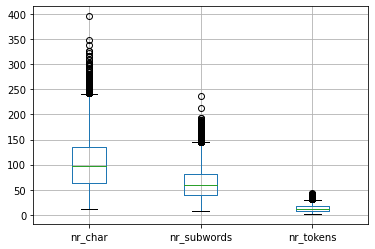

In [64]:
df_in[['nr_char', 'nr_subwords', 'nr_tokens']].boxplot()

Also look at the distribution of nr of characters per word: